In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import ttest_ind

In [70]:
customers = pd.read_csv(
    "../data/raw/customers.csv"
)

customers["churned"].value_counts()

customers["churned"].value_counts(normalize=True) * 100

churned
0    78.675
1    21.325
Name: proportion, dtype: float64

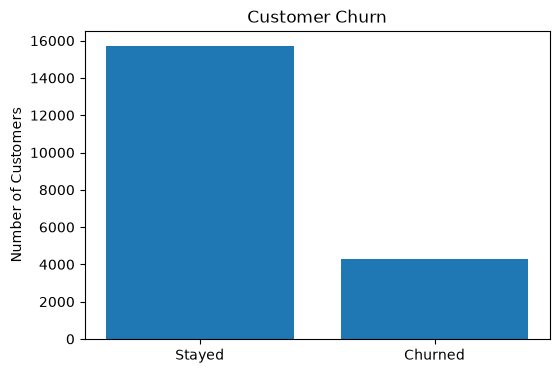

In [71]:
customers = pd.read_csv(
    "../data/raw/customers.csv"
)

churn_counts = customers["churned"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Stayed", "Churned"],
    churn_counts.values
)

plt.title("Customer Churn")
plt.ylabel("Number of Customers")

plt.show()

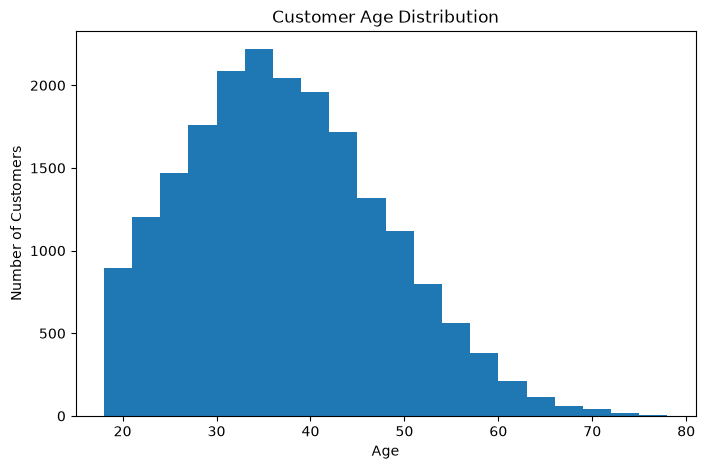

In [72]:
plt.figure(figsize=(8, 5))

plt.hist(
    customers["age"],
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

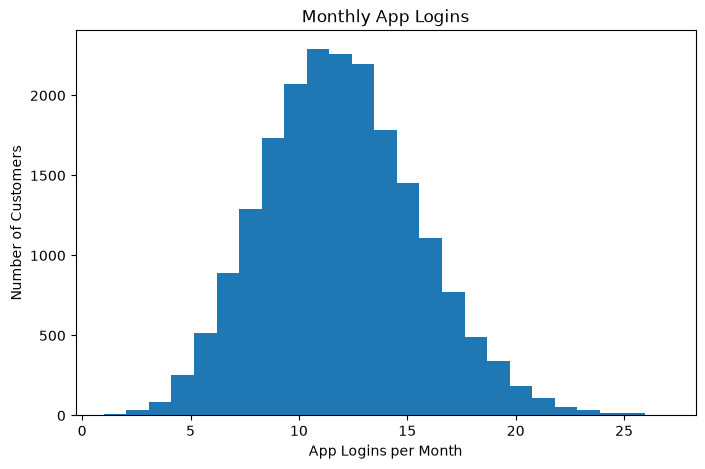

In [73]:
plt.figure(figsize=(8, 5))

plt.hist(
    customers["monthly_app_logins"],
    bins=25
)

plt.title("Monthly App Logins")
plt.xlabel("App Logins per Month")
plt.ylabel("Number of Customers")

plt.show()

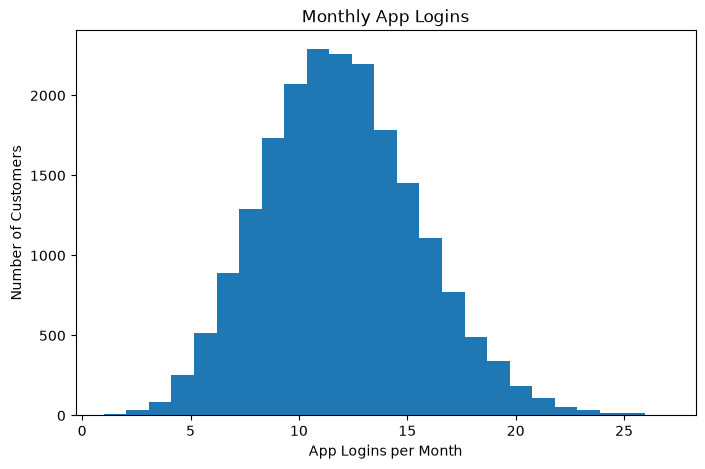

In [74]:
plt.figure(figsize=(8, 5))

plt.hist(
    customers["monthly_app_logins"],
    bins=25
)

plt.title("Monthly App Logins")
plt.xlabel("App Logins per Month")
plt.ylabel("Number of Customers")

plt.show()

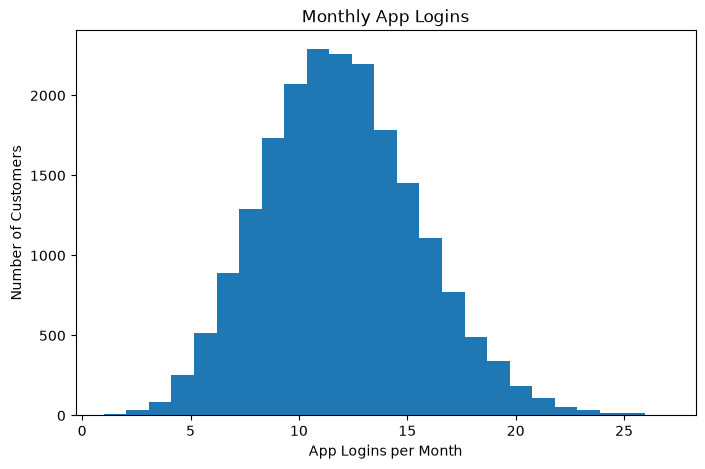

In [75]:
plt.figure(figsize=(8, 5))

plt.hist(
    customers["monthly_app_logins"],
    bins=25
)

plt.title("Monthly App Logins")
plt.xlabel("App Logins per Month")
plt.ylabel("Number of Customers")

plt.show()

In [78]:
customers.groupby("churned")["complaints"].mean()

churned
0    0.326724
1    0.692380
Name: complaints, dtype: float64

In [80]:
customers.groupby("churned")["customer_satisfaction"].mean()

churned
0    7.672641
1    6.764924
Name: customer_satisfaction, dtype: float64

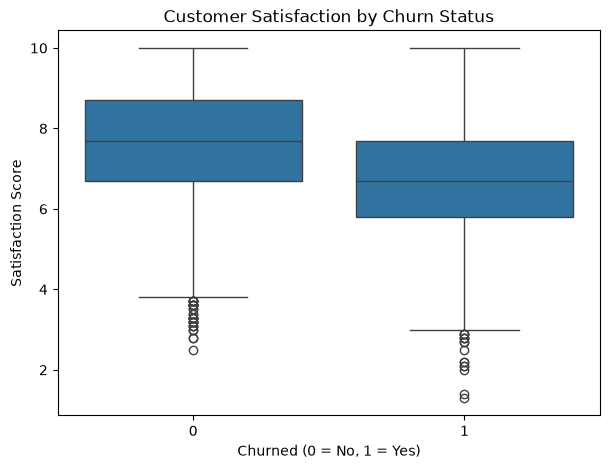

In [81]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=customers,
    x="churned",
    y="customer_satisfaction"
)

plt.title("Customer Satisfaction by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Satisfaction Score")

plt.show()

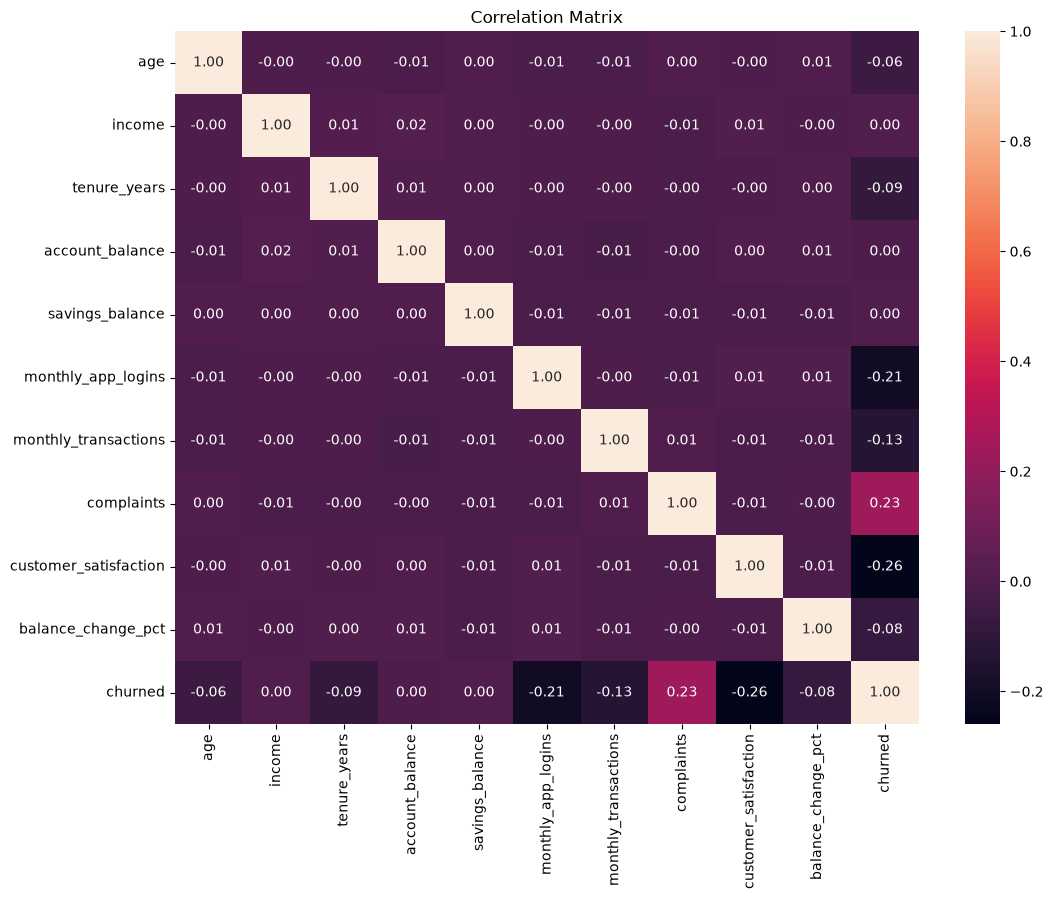

In [82]:
correlation_matrix = customers.drop(
    columns=["customer_id"]
).corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Time to test the signifcance of the number of app engagements ##

Null hypothesis (H₀):

There is no difference in average monthly app logins between customers who churn and customers who stay.

Alternative hypothesis (H₁):

There is a difference in average monthly app logins between customers who churn and customers who stay.

In [ ]:
stayed = customers[
    customers["churned"] == 0
]["monthly_app_logins"]

churned = customers[
    customers["churned"] == 1
]["monthly_app_logins"]

print(f"Stayed:   {stayed.mean():.2f}")
print(f"Churned:  {churned.mean():.2f}")

t_stat, p_value = ttest_ind(
    stayed,
    churned,
    equal_var=False
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("There is statistically significant evidence of a difference in app usage.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a difference in app usage.")


pooled_std = np.sqrt(
    (
        stayed.std() ** 2
        + churned.std() ** 2
    ) / 2
)

cohens_d = (
    stayed.mean() - churned.mean()
) / pooled_std

print(f"Cohen's d: {cohens_d:.3f}")

Stayed:   12.39
Churned:  10.65
t-statistic: 31.342
p-value: 0.000000
Reject the null hypothesis.
There is statistically significant evidence of a difference in app usage.
Cohen's d: 0.526


## Time to test the signifcance of customer satisfaction scores ##

Null hypothesis (H₀):

There is no difference in customer satisfaction between customers who churn and customers who stay.

Alternative hypothesis (H₁):

There is a difference in customer satisfaction between customers who churn and customers who stay.

In [93]:
stayed_satisfaction = customers[
    customers["churned"] == 0
]["customer_satisfaction"]

churned_satisfaction = customers[
    customers["churned"] == 1
]["customer_satisfaction"]

t_stat, p_value = ttest_ind(
    stayed_satisfaction,
    churned_satisfaction,
    equal_var=False
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("There is statistically significant evidence of a difference in satisfaction scores.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a difference in satisfaction scores.")

pooled_std = np.sqrt(
    (
        stayed_satisfaction.std() ** 2
        + churned_satisfaction.std() ** 2
    ) / 2
)

cohens_d = (
    stayed_satisfaction.mean() - churned_satisfaction.mean()
) / pooled_std

print(f"Cohen's d: {cohens_d:.3f}")

print(
    f"Stayed average satisfaction: "
    f"{stayed_satisfaction.mean():.2f}"
)

print(
    f"Churned average satisfaction: "
    f"{churned_satisfaction.mean():.2f}"
)

t-statistic: 37.175
p-value: 0.000000
Reject the null hypothesis.
There is statistically significant evidence of a difference in satisfaction scores.
Cohen's d: 0.649
Stayed average satisfaction: 7.67
Churned average satisfaction: 6.76


## Time to test the signifcance of number of customer complaints ##

Null hypothesis (H₀):

There is no difference in number of customer complaints between customers who churn and customers who stay.

Alternative hypothesis (H₁):

There is a difference in number of customer complaints between customers who churn and customers who stay.

In [95]:
stayed_complaints = customers[
    customers["churned"] == 0
]["complaints"]

churned_complaints = customers[
    customers["churned"] == 1
]["complaints"]

t_stat, p_value = ttest_ind(
    stayed_complaints,
    churned_complaints,
    equal_var=False
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("There is statistically significant evidence of a difference in complaint counts.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a difference in complaint counts.")

pooled_std = np.sqrt(
    (
        stayed_complaints.std() ** 2
        + churned_complaints.std() ** 2
    ) / 2
)

cohens_d = (
    stayed_complaints.mean() - churned_complaints.mean()
) / pooled_std

print(f"Cohen's d: {cohens_d:.3f}")

print(
    f"Stayed average complaints: "
    f"{stayed_complaints.mean():.2f}"
)

print(
    f"Churned average complaints: "
    f"{churned_complaints.mean():.2f}"
)

t-statistic: -28.087
p-value: 0.000000
Reject the null hypothesis.
There is statistically significant evidence of a difference in complaint counts.
Cohen's d: -0.529
Stayed average complaints: 0.33
Churned average complaints: 0.69


## Time to test the signifcance of age ##

Null hypothesis (H₀):

There is no difference in age between customers who churn and customers who stay.

Alternative hypothesis (H₁):

There is a difference in age between customers who churn and customers who stay.

In [98]:
stayed_age = customers[
    customers["churned"] == 0
]["age"]

churned_age = customers[
    customers["churned"] == 1
]["age"]

t_stat, p_value = ttest_ind(
    stayed_age,
    churned_age,
    equal_var=False
)

print(f"Stayed average age:  {stayed_age.mean():.2f}")
print(f"Churned average age: {churned_age.mean():.2f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")

pooled_std = np.sqrt(
    (
        stayed_age.std() ** 2
        + churned_age.std() ** 2
    ) / 2
)

cohens_d = (
    stayed_age.mean() - churned_age.mean()
) / pooled_std

print(f"Cohen's d: {cohens_d:.3f}")

Stayed average age:  37.16
Churned average age: 35.70
t-statistic: 8.213
p-value: 0.000000
Cohen's d: 0.141


Age was significantly associated with churn, with churned customers being approximately 1.5 years younger on average. However, the small Cohen's d (0.141) indicates that the practical effect of age is limited compared with customer satisfaction, complaints and engagement. Age may therefore provide useful predictive information, but is unlikely to be a primary driver of churn on its own.